In [2]:
from langgraph.graph import StateGraph
from typing import TypedDict, Dict, Any
from IPython.display import Image, display
import pandas as pd

#state
class LemonWorkflowState(TypedDict):
    lemons: int
    sugar: int
    water: str
    juice: str
    mix: str
    final: str
    fresh: bool
    seeds_removed: bool
    add_water: bool
    sweet: bool
    attempts: int

#Nodes

def wash_lemon(state: Dict[str, Any]) -> Dict[str, Any]:
    state["juice"] = "Lemons Washed"
    return state

def inspect_lemon(state: Dict[str, Any]) -> Dict[str, Any]:
    return state

def replace_lemon(state: Dict[str, Any]) -> Dict[str, Any]:
    state["lemons"] += 1
    state["fresh"] = True
    return state


def cut_lemon(state: Dict[str, Any]) -> Dict[str, Any]:
    state["juice"] = f"{state['lemons']} lemons cut"
    return state


def remove_seeds(state: Dict[str, Any]) -> Dict[str, Any]:
    state["seeds_removed"] = True
    return state

def skip_seed_removal(state: Dict[str, Any]) -> Dict[str, Any]:
    state["seeds_removed"] = False
    return state

def squeeze_juice(state: Dict[str, Any]) -> Dict[str, Any]:
    state["juice"] = f"Juice extracted from {state['lemons']} lemons"
    return state

def add_water(state: Dict[str, Any]) -> Dict[str, Any]:
    state["water"] = "Water Added"
    return state

def skip_water(state: Dict[str, Any]) -> Dict[str, Any]:
    state["water"] = "No Water"
    return state

def add_sugar(state: Dict[str, Any]) -> Dict[str, Any]:
    state["attempts"] += 1
    state["sugar"] += 2
    if state["attempts"] >= 2:
        state["sweet"] = True
    return state

def add_ice(state: Dict[str, Any]) -> Dict[str, Any]:
    state["mix"] = "Ice Added"
    return state

def serve(state: Dict[str, Any]) -> Dict[str, Any]:
    state["final"] = "Fresh Lemon Juice Ready"
    return state

#Routing

def freshness_route(state):
    if state["fresh"]:
        return "cut"
    return "replace"

def seed_route(state):
    if state["seeds_removed"]:
        return "squeeze"
    return "skip_seed"

def water_route(state):
    if state["add_water"]:
        return "water"
    return "skip_water"

def sweetness_route(state):
    if state["sweet"]:
        return "ice"
    return "sugar"

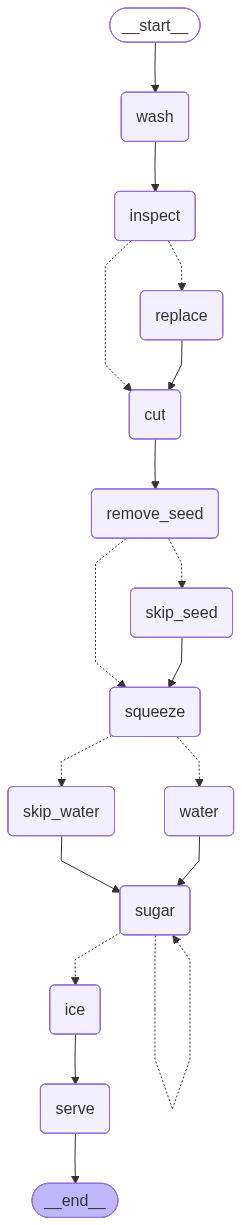

,lemons,sugar,water,juice,mix,final,fresh,seeds_removed,add_water,sweet,attempts
0,3,4,Water Added,Juice extracted from 3 lemons,Ice Added,Fresh Lemon Juice Ready,True,True,True,True,2


In [3]:
#Building graph
builder = StateGraph(LemonWorkflowState)

builder.add_node("wash", wash_lemon)
builder.add_node("inspect", inspect_lemon)
builder.add_node("replace", replace_lemon)
builder.add_node("cut", cut_lemon)
builder.add_node("remove_seed", remove_seeds)
builder.add_node("skip_seed", skip_seed_removal)
builder.add_node("squeeze", squeeze_juice)
builder.add_node("water", add_water)
builder.add_node("skip_water", skip_water)
builder.add_node("sugar", add_sugar)
builder.add_node("ice", add_ice)
builder.add_node("serve", serve)

builder.set_entry_point("wash")

builder.add_edge("wash","inspect")

builder.add_conditional_edges("inspect", freshness_route, {"cut": "cut","replace": "replace"})

builder.add_edge("replace","cut")
builder.add_edge("cut","remove_seed")

builder.add_conditional_edges("remove_seed",seed_route,{"squeeze":"squeeze","skip_seed":"skip_seed"})

builder.add_edge("skip_seed","squeeze")

builder.add_conditional_edges("squeeze", water_route, { "water":"water", "skip_water":"skip_water"})

builder.add_edge("water","sugar")
builder.add_edge("skip_water","sugar")
builder.add_conditional_edges("sugar",sweetness_route, {"sugar":"sugar", "ice":"ice"})

builder.add_edge("ice","serve")
builder.set_finish_point("serve")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

initial_state = {
    "lemons":2,
    "sugar":0,
    "water":"",
    "juice":"",
    "mix":"",
    "final":"",
    "fresh":False,
    "seeds_removed":True,
    "add_water":True,
    "sweet":False,
    "attempts":0
}

result = graph.invoke(initial_state)
result_df = pd.DataFrame([result])
result_df